In [ ]:
# ДОМАШАНЕЕ ЗАДАНИЕ
# Текстурные характеристики:
#  - Реализуйте подсчет гистограммы
#  - Реализуйте рассчет текстурных характеристик Laws
#  - Реализуйте расчет текстурных характеристик на основе матрицы взаимной встречаемости GLCM
# Для каждого случая: выполните тренировку классификатора (knn, svm, trees)
# Решите задачу сегментации данных на основе классификации изображений каждым методом.
# Выполните ручную разметку изображений на регионы.
# Сравните результат полученной классификации и размеченной.

DATA ROOT: /content | folder_as_class: False
Found images: 6
 1. /content/3.jpg
 2. /content/4.jpg
 3. /content/5.png
 4. /content/6.png
 5. /content/images (1).jfif
 6. /content/images (2).jfif
X shape: (6, 129) | #classes: 6

=== TRAIN-ONLY REPORT (no split) ===
kNN: train acc = 0.333
              precision    recall  f1-score   support

           3       0.33      1.00      0.50         1
           4       0.00      0.00      0.00         1
           5       0.50      1.00      0.67         1
           6       0.00      0.00      0.00         1
  images (1)       0.00      0.00      0.00         1
  images (2)       0.00      0.00      0.00         1

    accuracy                           0.33         6
   macro avg       0.14      0.33      0.19         6
weighted avg       0.14      0.33      0.19         6

------------------------------------------------------------
SVM: train acc = 1.000
              precision    recall  f1-score   support

           3       1.00      1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


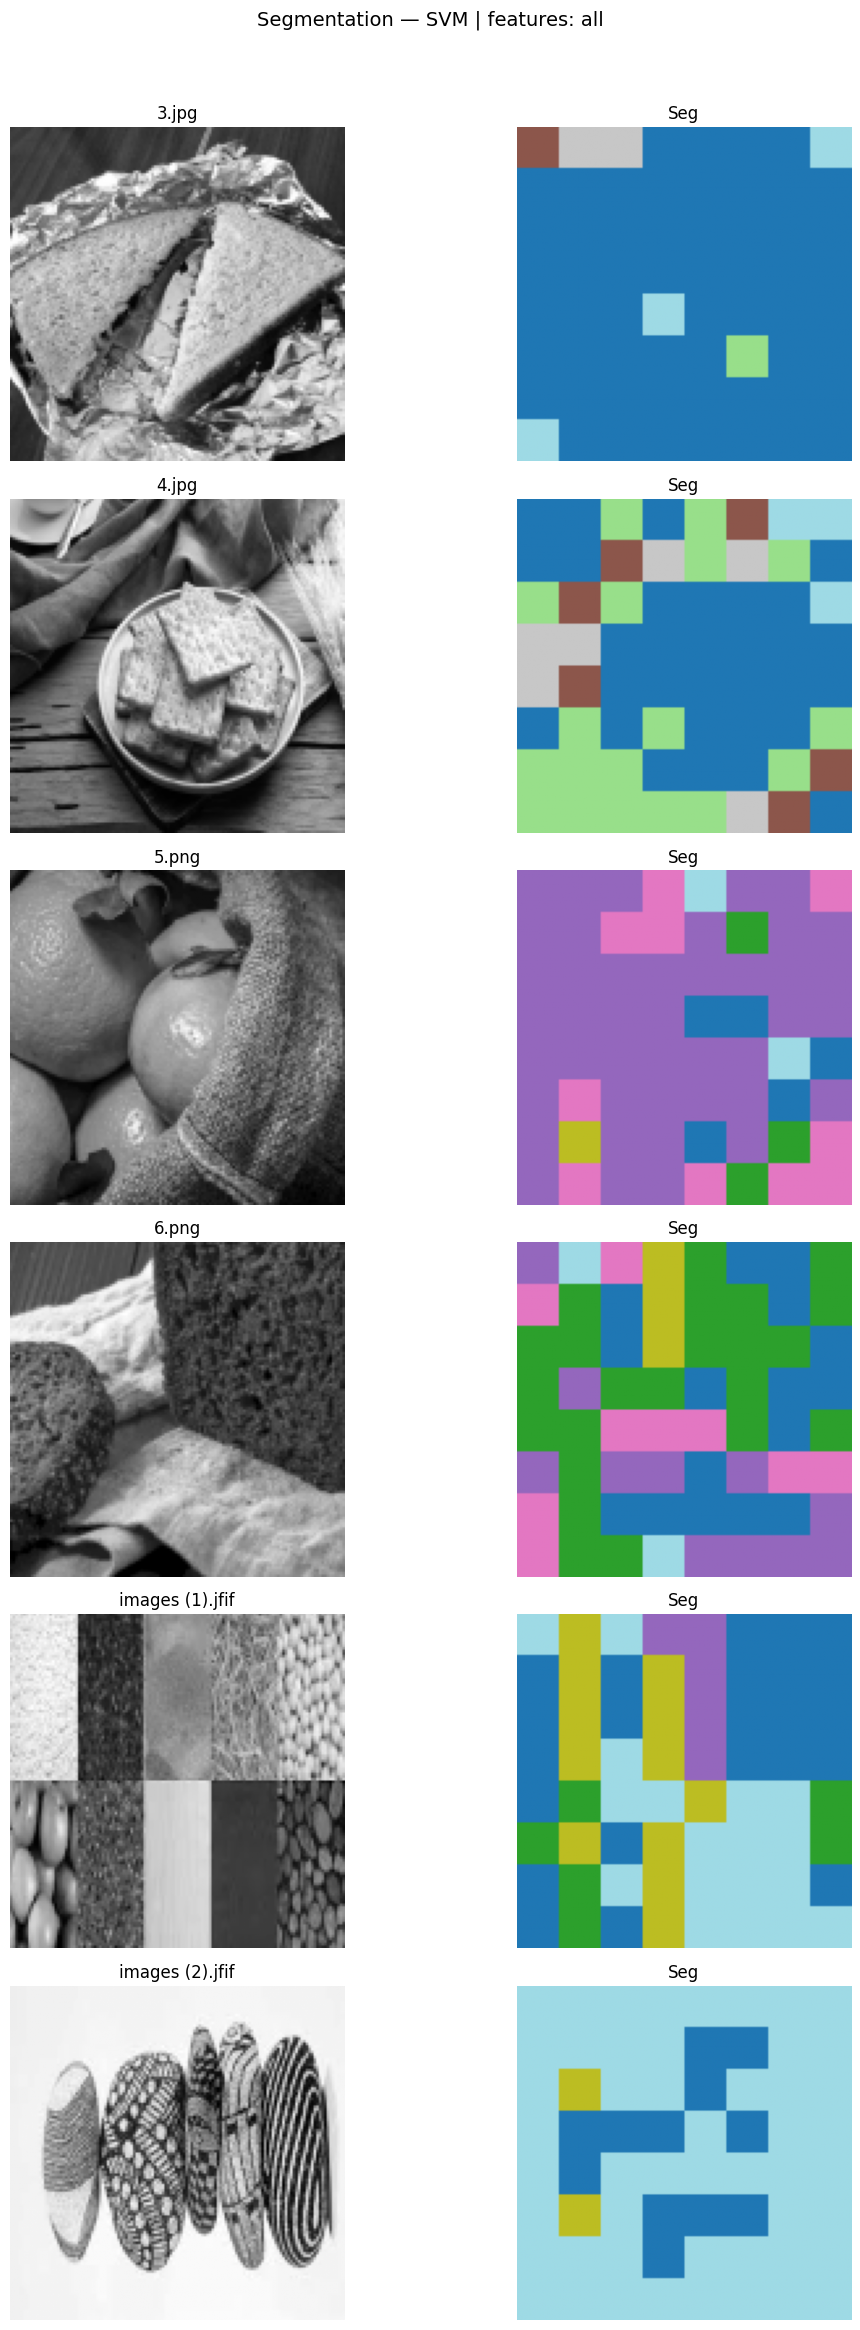

In [38]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

def _import_glcm():
    try:
        from skimage.feature.texture import graycomatrix, graycoprops
        return graycomatrix, graycoprops
    except Exception:
        pass
    try:
        from skimage.feature.texture import greycomatrix as graycomatrix, greycoprops as graycoprops
        return graycomatrix, graycoprops
    except Exception:
        pass
    try:
        from skimage.feature import graycomatrix, graycoprops
        return graycomatrix, graycoprops
    except Exception:
        from skimage.feature import greycomatrix as graycomatrix, greycoprops as graycoprops
        return graycomatrix, graycoprops
graycomatrix, graycoprops = _import_glcm()
from skimage import img_as_ubyte

ROOTS          = ["/content/data", "/content"]
EXCLUDE_DIRS   = {"seg", "sample_data", ".ipynb_checkpoints", "__pycache__"}
EXTS           = (".jpg",".jpeg",".png",".jfif",".bmp",".tif",".tiff")
IMG_SIZE       = (128, 128)
PATCH          = 16
FEATURE_MODE   = "all"
USE_TRAIN_ONLY = True
TEST_SIZE      = 0.3
RANDOM_STATE   = 42

def _has_images(path):
    return any(f.lower().endswith(EXTS) for f in os.listdir(path))

def find_root_and_mode():
    for r in ROOTS:
        if not os.path.exists(r):
            continue
        subdirs = [d for d in sorted(os.listdir(r)) if os.path.isdir(os.path.join(r,d))]
        classlike = [d for d in subdirs if _has_images(os.path.join(r,d))]
        if len(classlike) >= 2:
            return r, True
        if _has_images(r):
            return r, False
    raise RuntimeError("No images found. Put files in /content or /content/data")

root, folder_as_class = find_root_and_mode()
print("DATA ROOT:", root, "| folder_as_class:", folder_as_class)

def collect_paths(root, folder_as_class):
    paths, labels = [], []
    if folder_as_class:
        for cls in sorted(os.listdir(root)):
            pcls = os.path.join(root, cls)
            if not os.path.isdir(pcls):
                continue
            if any(part in EXCLUDE_DIRS for part in os.path.relpath(pcls, "/content").split(os.sep)):
                continue
            for fn in sorted(os.listdir(pcls)):
                if fn.lower().endswith(EXTS):
                    paths.append(os.path.join(pcls, fn))
                    labels.append(cls)
    else:
        for fn in sorted(os.listdir(root)):
            n = fn.lower()
            if n.endswith(EXTS) and not n.startswith("seg_"):
                paths.append(os.path.join(root, fn))
                labels.append(os.path.splitext(fn)[0])
    return paths, labels

image_paths, label_names = collect_paths(root, folder_as_class)
print(f"Found images: {len(image_paths)}")
for i,p in enumerate(image_paths[:10],1):
    print(f"{i:2d}. {p}")
if len(image_paths) > 10:
    print(f"... and {len(image_paths)-10} more")

def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot read {path}")
    return cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

images = [read_gray(p) for p in image_paths]
le = LabelEncoder()
Y = le.fit_transform(label_names)


def feats_histogram(img, bins=32):
    hist = cv2.calcHist([img],[0],None,[bins],[0,256]).flatten().astype(np.float32)
    return hist / (hist.sum() + 1e-8)

def _laws_kernels():
    L5 = np.array([1,4,6,4,1],np.float32)
    E5 = np.array([-1,-2,0,2,1],np.float32)
    S5 = np.array([-1,0,2,0,-1],np.float32)
    R5 = np.array([1,-4,6,-4,1],np.float32)
    W5 = np.array([-1,2,0,-2,1],np.float32)
    vec=[L5,E5,S5,R5,W5]
    return [np.outer(a,b) for a in vec for b in vec]
K_LAWS = _laws_kernels()

def feats_laws(img):
    f = img.astype(np.float32)
    f -= cv2.blur(f,(15,15))
    e = [cv2.blur(cv2.filter2D(f,-1,k)**2,(15,15)).mean() for k in K_LAWS]
    return np.asarray(e, np.float32)

def feats_glcm(img):
    g = graycomatrix(img_as_ubyte(img), [1,2,4],
                     [0,np.pi/4,np.pi/2,3*np.pi/4],
                     256, symmetric=True, normed=True)
    props=[]
    for p in ("contrast","dissimilarity","homogeneity","ASM","energy","correlation"):
        props.extend(graycoprops(g,p).flatten().tolist())
    return np.asarray(props, np.float32)

def feats_all(img, mode):
    if mode == "hist": return feats_histogram(img)
    if mode == "laws": return feats_laws(img)
    if mode == "glcm": return feats_glcm(img)
    if mode == "all":  return np.concatenate([feats_histogram(img), feats_laws(img), feats_glcm(img)]).astype(np.float32)
    raise ValueError("FEATURE_MODE must be: 'hist'|'laws'|'glcm'|'all'")

X = np.vstack([feats_all(im, FEATURE_MODE) for im in images])
print("X shape:", X.shape, "| #classes:", len(le.classes_))


models = {
    "kNN":  KNeighborsClassifier(n_neighbors=3),
    "SVM":  SVC(kernel='linear'),
    "Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

if USE_TRAIN_ONLY:
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)
    print("\n=== TRAIN-ONLY REPORT (no split) ===")
    best_name, best_acc, best_model = None, -1, None
    for name, clf in models.items():
        clf.fit(Xs, Y)
        pred = clf.predict(Xs)
        acc = accuracy_score(Y, pred)
        print(f"{name}: train acc = {acc:.3f}")
        print(classification_report(Y, pred, target_names=le.classes_))
        print("-"*60)
        if acc > best_acc:
            best_acc, best_name, best_model = acc, name, clf
else:

    try:
        trainX, testX, trainY, testY = train_test_split(
            X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=Y
        )
        print("Split: stratified")
    except ValueError:
        trainX, testX, trainY, testY = train_test_split(
            X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True, stratify=None
        )
        print("Split: plain (no stratify)")

    scaler = StandardScaler().fit(trainX)
    trainX_s = scaler.transform(trainX)
    testX_s  = scaler.transform(testX)

    print("\n=== TEST REPORT ===")
    best_name, best_acc, best_model = None, -1, None
    for name, clf in models.items():
        clf.fit(trainX_s, trainY)
        pred = clf.predict(testX_s)
        acc = accuracy_score(testY, pred)
        print(f"{name}: test acc = {acc:.3f}")
        print(classification_report(testY, pred, target_names=le.classes_))
        print("-"*60)
        if acc > best_acc:
            best_acc, best_name, best_model = acc, name, clf

print(f"Best model: {best_name} | features: {FEATURE_MODE}")


def segment_image(img, model, scaler, mode, patch=PATCH):
    H, W = img.shape
    seg = np.zeros((H//patch, W//patch), dtype=np.int32)
    for y in range(0, H-patch+1, patch):
        for x in range(0, W-patch+1, patch):
            patch_img = img[y:y+patch, x:x+patch]
            f = feats_all(patch_img, mode)[None, :]
            f = scaler.transform(f)
            seg[y//patch, x//patch] = model.predict(f)[0]
    return cv2.resize(seg, (W, H), interpolation=cv2.INTER_NEAREST)

os.makedirs("/content/seg", exist_ok=True)
nrows, ncols = len(images), 2
plt.figure(figsize=(6*ncols, 3.8*nrows))
plt.suptitle(f"Segmentation — {best_name} | features: {FEATURE_MODE}", y=1.02, fontsize=14)

for i, (im, pth) in enumerate(zip(images, image_paths), 1):
    seg = segment_image(im, best_model, scaler, FEATURE_MODE, patch=PATCH)
    out_path = f"/content/seg/seg_{best_name}_{FEATURE_MODE}_{os.path.basename(pth)}.png"
    cv2.imwrite(out_path, seg)
    plt.subplot(nrows, ncols, 2*i-1); plt.imshow(im, cmap='gray'); plt.title(os.path.basename(pth)); plt.axis("off")
    plt.subplot(nrows, ncols, 2*i);   plt.imshow(seg, cmap="tab20"); plt.title("Seg"); plt.axis("off")

plt.tight_layout(); plt.show()

In [36]:
!rm -rf /content/seg
